# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [4]:
df_california = pd.read_csv('california_dataset.csv')

In [5]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(df_california, test_size=0.2, random_state=42)

df_california.columns


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'house_price'],
      dtype='object')

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

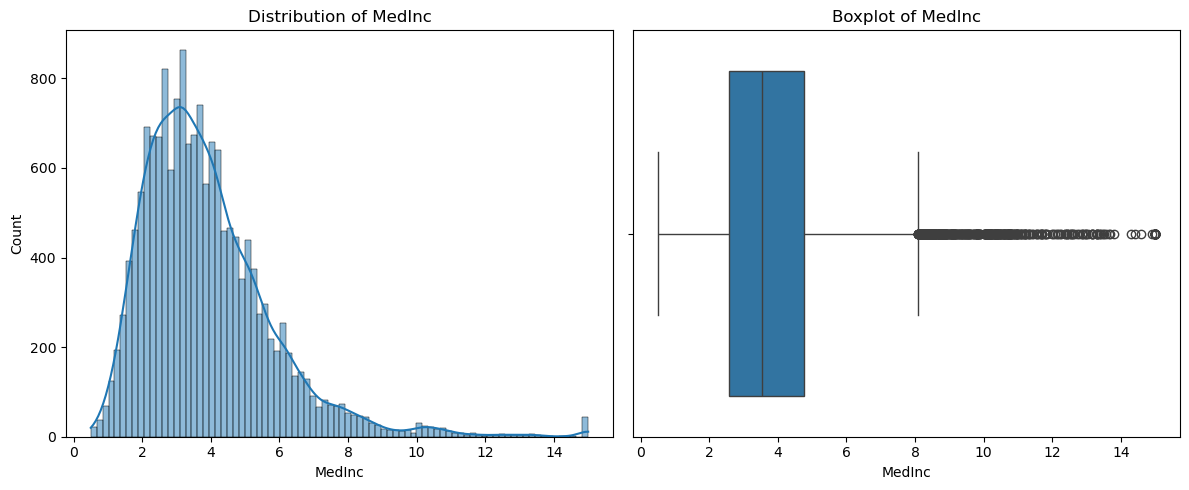

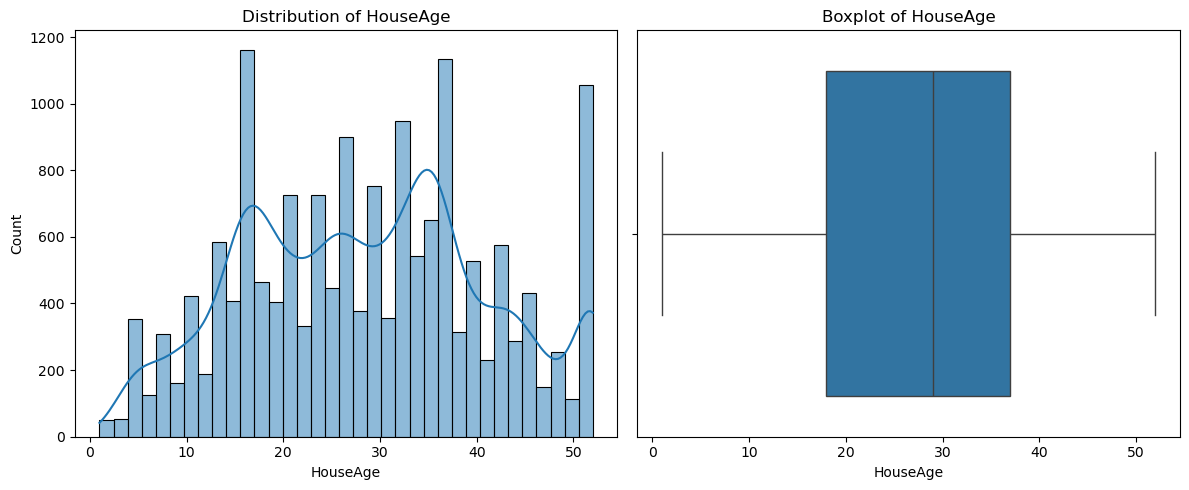

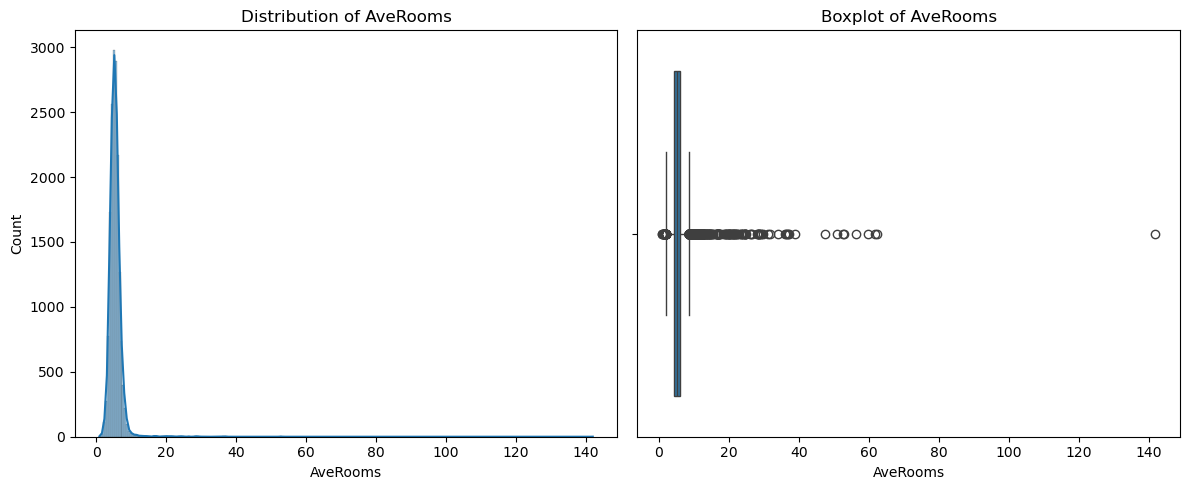

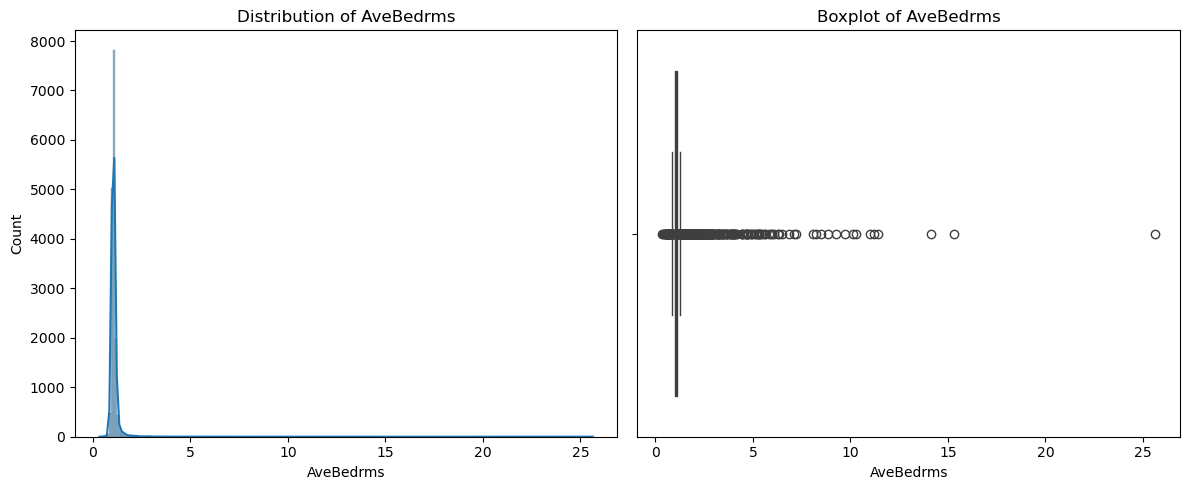

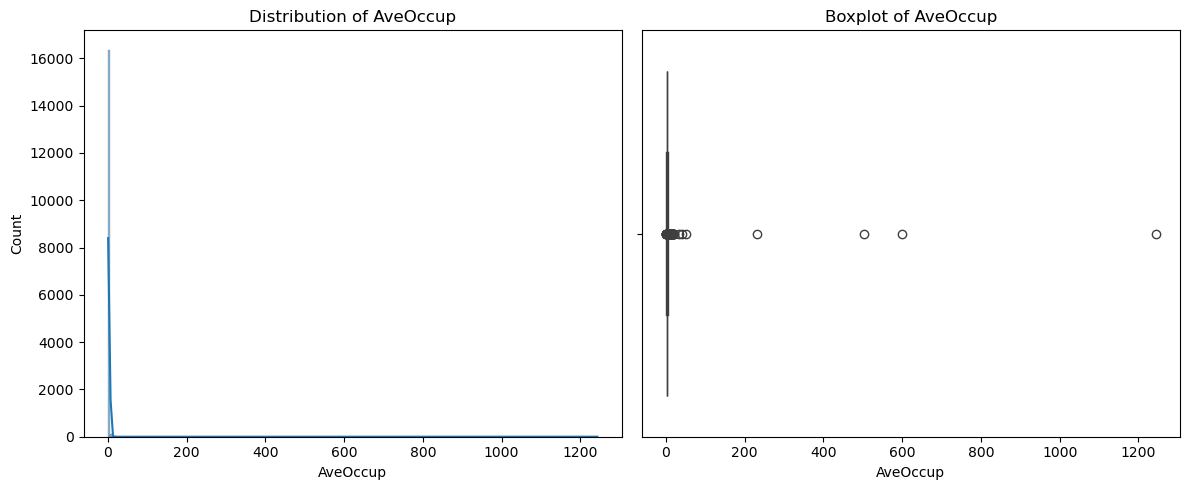

In [7]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
check_columns = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Daftar nama kolom yang ingin Anda cek
for column in check_columns:
    plt.figure(figsize=(12, 5))
   
    # Plot distribusi data
    plt.subplot(1, 2, 1)
    sns.histplot(train_clfr[column], kde=True)
    plt.title(f'Distribution of {column}')

    # Plot boxplot untuk melihat outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_clfr[column])
    plt.title(f'Boxplot of {column}')

    plt.tight_layout()
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [12]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali

def handle_outliers_iqr(df, variable):
    Q1 = df_california[variable].quantile(0.25)
    Q3 = df_california[variable].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return upper_bound, lower_bound

MedInc_upper_limit, MedInc_lower_limit = handle_outliers_iqr(train_clfr, 'MedInc')
MedInc_upper_limit, MedInc_lower_limit

(np.float64(8.013024999999999), np.float64(-0.7063750000000004))

In [15]:
train_clfr['MedInc'] = np.where(
    train_clfr['MedInc'] > MedInc_upper_limit, MedInc_upper_limit,
    np.where(
        train_clfr['MedInc'] < MedInc_lower_limit, MedInc_lower_limit, train_clfr['MedInc'])
)

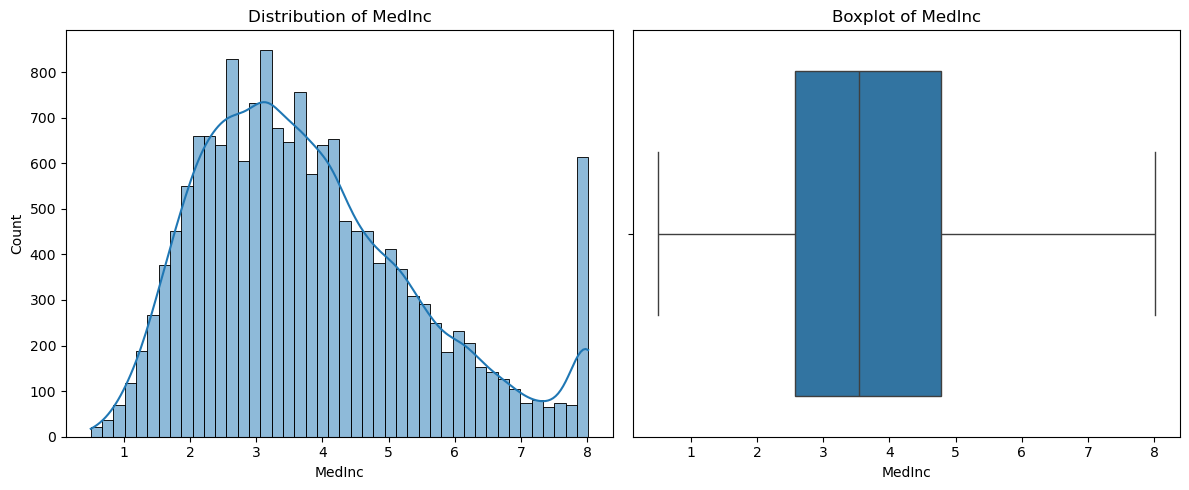

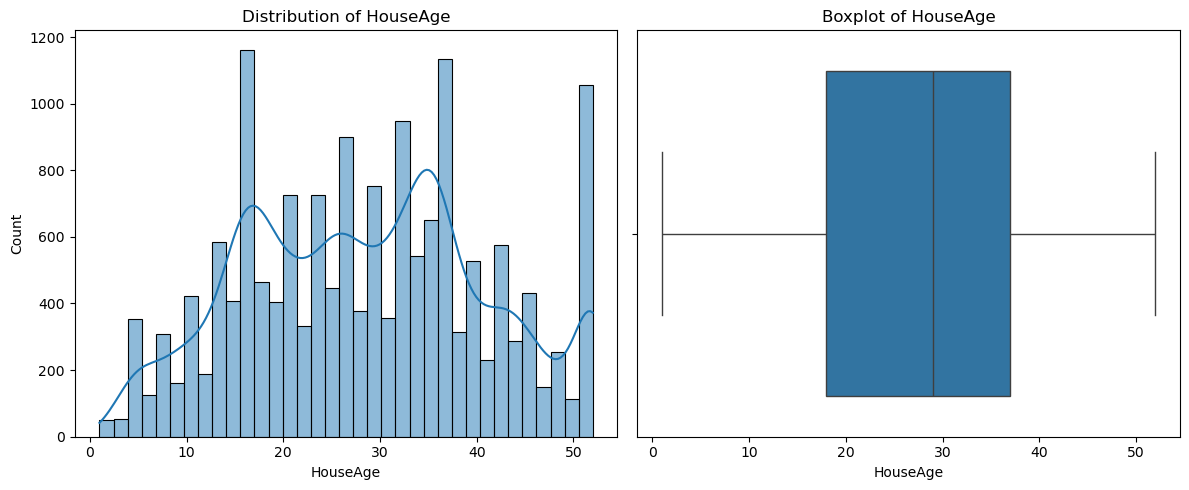

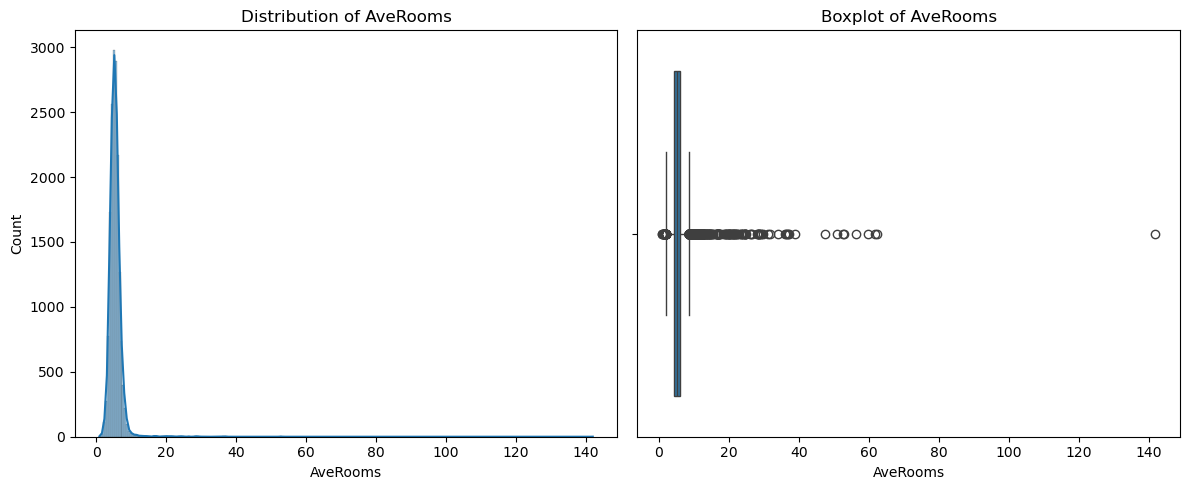

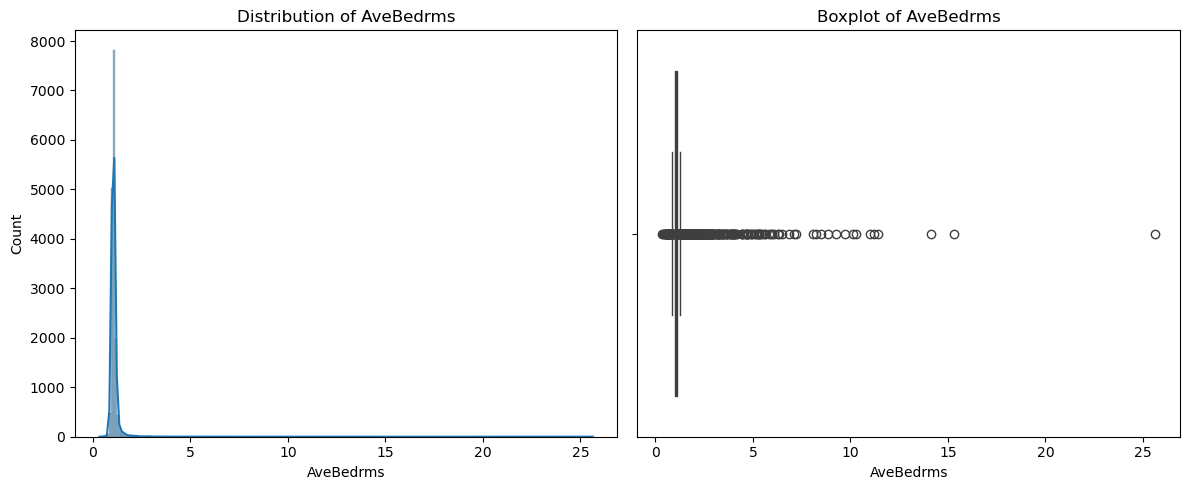

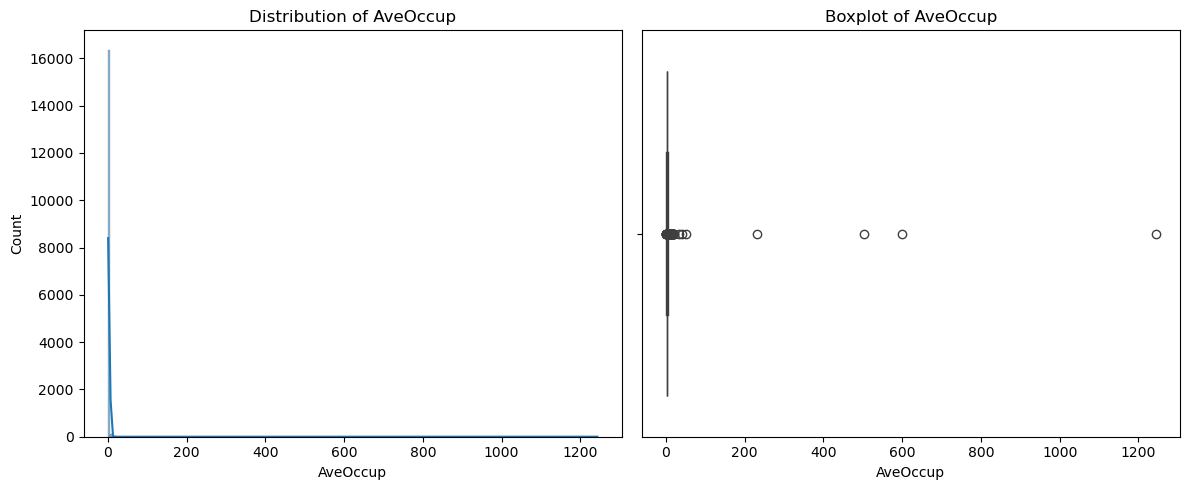

In [16]:
# Melakukan loop untuk mengecek distribusi tiap kolom

for column in check_columns:
    plt.figure(figsize=(12, 5))
   
    # Plot distribusi data
    plt.subplot(1, 2, 1)
    sns.histplot(train_clfr[column], kde=True)
    plt.title(f'Distribution of {column}')

    # Plot boxplot untuk melihat outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_clfr[column])
    plt.title(f'Boxplot of {column}')

    plt.tight_layout()
    plt.show()



# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [17]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [18]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
train_company, test_company = train_test_split(df_company, test_size=0.2, random_state=42)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [19]:
#Tulis jawaban missing value handling kolom Headquarters disini
train_company.isna().sum()


Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

In [ ]:
train_company['Headquarters'].value_counts()

Headquarters
New York, NY                 29
San Francisco, CA            28
-1                           24
Chicago, IL                  20
Boston, MA                   13
Mc Lean, VA                  12
Westminster, CO              10
Reston, VA                    9
Cambridge, MA                 8
Cambridge, United Kingdom     8
Vienna, VA                    7
Bedford, MA                   7
San Jose, CA                  7
Woodbine, MD                  6
Mountain View, CA             6
Herndon, VA                   6
Saint Louis, MO               6
Arlington, VA                 6
Washington, DC                6
San Antonio, TX               5
Los Angeles, CA               5
Denver, CO                    5
Chantilly, VA                 5
Bethesda, MD                  5
Orlando, FL                   4
Houston, TX                   4
San Rafael, CA                4
Pittsburgh, PA                4
Bellevue, WA                  4
McLean, VA                    4
Princeton, NJ              

In [23]:
# ada anomali -1
100 *len(train_company[train_company['Headquarters'].isin(['-1'])]) / len(train_company)

4.4692737430167595

In [ ]:
# modus dari kolom Headquarters

modus_headquarters = train_company[train_company['Headquarters']!= '-1']['Headquarters'].mode()[0]
modus_headquarters

'New York, NY'

In [26]:
train_company['Headquarters'] = train_company['Headquarters'].apply(lambda x: modus_headquarters if x == '-1' else x)
train_company['Headquarters'].value_counts()

Headquarters
New York, NY                 53
San Francisco, CA            28
Chicago, IL                  20
Boston, MA                   13
Mc Lean, VA                  12
Westminster, CO              10
Reston, VA                    9
Cambridge, United Kingdom     8
Cambridge, MA                 8
San Jose, CA                  7
Bedford, MA                   7
Vienna, VA                    7
Woodbine, MD                  6
Mountain View, CA             6
Arlington, VA                 6
Herndon, VA                   6
Washington, DC                6
Saint Louis, MO               6
San Antonio, TX               5
Denver, CO                    5
Los Angeles, CA               5
Chantilly, VA                 5
Bethesda, MD                  5
Orlando, FL                   4
Pleasanton, CA                4
Memphis, TN                   4
Raleigh, NC                   4
Princeton, NJ                 4
Santa Cruz, CA                4
Austin, TX                    4
San Rafael, CA             

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [28]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [29]:
#Splitting terlebih dahulu
from sklearn.model_selection import train_test_split
train_churn, tes_churn = train_test_split(df_churn, test_size=0.2, random_state=42)


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [40]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

collumns_picky = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']
for column in collumns_picky:
    print(f'Encoding column: {column}')
    display(train_churn[column].value_counts())
    print()

Encoding column: StreamingMovies


StreamingMovies
0    3437
1    2197
Name: count, dtype: int64


Encoding column: StreamingTV


StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64


Encoding column: TechSupport


...

OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64


Encoding column: OnlineSecurity


OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64


Encoding column: MultipleLines


MultipleLines
No     3237
Yes    2397
Name: count, dtype: int64

In [41]:
train_churn['StreamingMovies'] = train_churn['StreamingMovies'].replace({'No internet service': 'No'})
train_churn['StreamingTV'] = train_churn['StreamingTV'].replace({'No internet service': 'No'})
train_churn['TechSupport'] = train_churn['TechSupport'].replace({'No internet service': 'No'})
train_churn['DeviceProtection'] = train_churn['DeviceProtection'].replace({'No internet service': 'No'})
train_churn['OnlineBackup'] = train_churn['OnlineBackup'].replace({'No internet service': 'No'})
train_churn['OnlineSecurity'] = train_churn['OnlineSecurity'].replace({'No internet service': 'No'})
train_churn['MultipleLines'] = train_churn['MultipleLines'].replace({'No phone service': 'No'})

for column in collumns_picky:
    print(f'Encoding column: {column}')
    display(train_churn[column].value_counts())
    print()

Encoding column: StreamingMovies


StreamingMovies
0    3437
1    2197
Name: count, dtype: int64


Encoding column: StreamingTV


StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64


Encoding column: TechSupport


...

OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64


Encoding column: OnlineSecurity


OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64


Encoding column: MultipleLines


MultipleLines
No     3237
Yes    2397
Name: count, dtype: int64

In [42]:
collumns_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

label_encoder = LabelEncoder()

In [44]:
for column in collumns_to_encode:
    train_churn[column] = label_encoder.fit_transform(train_churn[column])

train_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2142,4223-BKEOR,Female,0,No,Yes,21,Yes,0,DSL,1,0,1,0,0,1,One year,No,Mailed check,64.85,1336.8,No
1623,6035-RIIOM,Female,0,No,No,54,Yes,1,Fiber optic,0,1,0,0,1,1,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
6074,3797-VTIDR,Male,0,Yes,No,1,No,0,DSL,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
1362,2568-BRGYX,Male,0,No,No,4,Yes,0,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
6754,2775-SEFEE,Male,0,No,Yes,0,Yes,1,DSL,1,1,0,1,0,0,Two year,Yes,Bank transfer (automatic),61.90,,No


## Selesai :)